---

**Probabilistic Artificial Intelligence: Parameter and Structure Learning**

---


**Contents:**

--------
1. Parameter Learning in a Bayes Net
2. Structure Learning in a Bayes Net




### 1. Short context

So far we have been focused on how Bayesian networks efficiently encode a probability distribution over a set of variables.
This tutorial will be about obtaining a Bayesian network, given a set of sample data. First we focus on the problem of **parameter Learning** for a given network and secondly on **learning the structure** itself.




## 2. Parameter Learning in a Bayes Net
### 2.1. Introductory example


In [4]:
!pip install -U pgmpy

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---- ----------------------------------- 0.2/2.0 MB 7.6 MB/s eta 0:00:01
   ----------- ---------------------------- 0.6/2.0 MB 7.0 MB/s eta 0:00:01
   --------------- ------------------------ 0.8/2.0 MB 5.4 MB/s eta 0:00:01
   ------------------ --------------------- 0.9/2.0 MB 4.8 MB/s eta 0:00:01
   -------------------- ------------------- 1.0/2.0 MB 4.6 MB/s eta 0:00:01
   ---------------------- ----------------- 1.1/2.0 MB 4.2 MB/s eta 0:00:01
   ------------------------ --------------- 1.2/2.0 MB 3.8 MB/s eta 0:00:01
   ------------------------- -------------- 1.3/2.0 MB 3.6 MB/s eta 0:00:01
   -------------------------- ------------- 1.4/2.0 MB 3.3 MB/s eta 0:00:01
   ---------------------------- ----------- 1.4/2.0 MB 3.1 MB/s eta 0:00:01
   ----------------------------- ---------- 1.5/2.0 MB 3.0 MB/s eta 0:00:01
   ------------------------------

In [6]:
import pgmpy
pgmpy.__version__

OSError: [WinError 1114] Falha numa rotina de inicialização de DLL (dynamic-link library). Error loading "c:\Users\ASUS\anaconda3\Lib\site-packages\torch\lib\c10.dll" or one of its dependencies.

In [1]:
# Based on https://pgmpy.org/detailed_notebooks/10.%20Learning%20Bayesian%20Networks%20from%20Data.html
import numpy as np
import pandas as pd
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator
from pgmpy.estimators import MaximumLikelihoodEstimator

pd.set_option('display.max_columns', None)

/Users/vcerq/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# dataset
data = pd.DataFrame(data={'fruit': ["banana", "apple", "banana", "apple", "banana","apple", "banana",
                                    "apple", "apple", "apple", "banana", "banana", "apple", "banana",],
                          'tasty': ["yes", "no", "yes", "yes", "yes", "yes", "yes",
                                    "yes", "yes", "yes", "yes", "no", "no", "no"],
                          'size': ["large", "large", "large", "small", "large", "large", "large",
                                    "small", "large", "large", "large", "large", "small", "small"]})

data


,fruit,tasty,size
0,banana,yes,large
1,apple,no,large
2,banana,yes,large
3,apple,yes,small
4,banana,yes,large
5,apple,yes,large
6,banana,yes,large
7,apple,yes,small
8,apple,yes,large
9,apple,yes,large


In [3]:
?DiscreteBayesianNetwork

model = DiscreteBayesianNetwork(
    [
        ('fruit', 'tasty'), 
        ('size', 'tasty')
     ]) 

Init signature:
DiscreteBayesianNetwork(
    ebunch=None,
    latents=set(),
    lavaan_str=None,
    dagitty_str=None,
)
Docstring:     
Initializes a Bayesian Network.
A models stores nodes and edges with conditional probability
distribution (cpd) and other attributes.

Models hold directed edges.  Self loops are not allowed neither
multiple (parallel) edges.

Nodes can be any hashable python object.

Edges are represented as links between nodes.

Parameters
----------
ebunch: input graph
    Data to initialize graph.  If ebunch=None (default) an empty
    graph is created.  The ebunch can be an edge list, or any
    NetworkX graph object.

latents: list, array-like
    List of variables which are latent (i.e. unobserved) in the model.

Examples
--------
Create an empty Bayesian Network with no nodes and no edges.

>>> from pgmpy.models import DiscreteBayesianNetwork
>>> G = DiscreteBayesianNetwork()

G can be grown in several ways.

**Nodes:**

Add one node at a time:

>>> G.add_nod

In [4]:
# Using a MLE estimator to obtain the CPDs tables
model.fit(data, estimator=MaximumLikelihoodEstimator)

CPDs = model.get_cpds()
for cpd in CPDs:
    try:
        print(cpd.to_dataframe())
    except ValueError:
        print(cpd)

    print('\n###')


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'fruit': 'C', 'tasty': 'C', 'size': 'C'}


+---------------+-----+
| fruit(apple)  | 0.5 |
+---------------+-----+
| fruit(banana) | 0.5 |
+---------------+-----+

###
tasty               no       yes
fruit  size                     
apple  large  0.250000  0.750000
       small  0.333333  0.666667
banana large  0.166667  0.833333
       small  1.000000  0.000000

###
+-------------+----------+
| size(large) | 0.714286 |
+-------------+----------+
| size(small) | 0.285714 |
+-------------+----------+

###


In [8]:
?BayesianEstimator

Init signature: BayesianEstimator(model, data, **kwargs)
Docstring:     
Class used to compute parameters for a model using Bayesian Parameter Estimation.
See `MaximumLikelihoodEstimator` for constructor parameters.
Init docstring:
Base class for parameter estimators in pgmpy.

Parameters
----------
model: pgmpy.models.DiscreteBayesianNetwork or pgmpy.models.MarkovNetwork model
    for which parameter estimation is to be done.

data: pandas DataFrame object
    dataframe object with column names identical to the variable names of the model.
    (If some values in the data are missing the data cells should be set to `numpy.nan`.
    Note that pandas converts each column containing `numpy.nan`s to dtype `float`.)

state_names: dict (optional)
    A dict indicating, for each variable, the discrete set of states (or values)
    that the variable can take. If unspecified, the observed values in the data set
    are taken to be the only possible states.

complete_samples_only: bool (optional

In [11]:
# Using a Bayesian estimator to obtain the CPDs tables
model.fit(data, estimator=BayesianEstimator, prior_type="BDeu", equivalent_sample_size=10)

CPDs = model.get_cpds()
for cpd in CPDs:
    try:
        print(cpd.to_dataframe())
    except ValueError:
        print(cpd)

    print('\n###')

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'fruit': 'C', 'tasty': 'C', 'size': 'C'}


+---------------+-----+
| fruit(apple)  | 0.5 |
+---------------+-----+
| fruit(banana) | 0.5 |
+---------------+-----+

###
tasty               no       yes
fruit  size                     
apple  large  0.346154  0.653846
       small  0.409091  0.590909
banana large  0.264706  0.735294
       small  0.642857  0.357143

###
+-------------+-------+
| size(large) | 0.625 |
+-------------+-------+
| size(small) | 0.375 |
+-------------+-------+

###


## 2.2. Questions
Based on the previous code answer the following questions:

1. For MLE, why small bananas are not tasty?
2. Why the CPDs tables for MLE and Bayesian estimators differ?
3. What is the goal of the *prior_type*?

## 3. Structure Learning
### 3.1. Scoring function. Example 1:

In [ ]:
from pgmpy.estimators import K2, BIC, BDeu

bdeu = BDeu(data, equivalent_sample_size=5)
k2 = K2(data)
bic = BIC(data)

# fruit -> tasty <- size
model1 = DiscreteBayesianNetwork([('fruit', 'tasty'), ('size', 'tasty')]) 
# fruit <- tasty -> size
model2 = DiscreteBayesianNetwork([('tasty', 'fruit'), ('tasty', 'size')]) 

print('BDeu')
print(bdeu.score(model1))
print(bdeu.score(model2))
print('K2')
print(k2.score(model1))
print(k2.score(model2))
print('BIC')
print(bic.score(model1))
print(bic.score(model2))


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'fruit': 'C', 'tasty': 'C', 'size': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'fruit': 'C', 'tasty': 'C', 'size': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'fruit': 'C', 'tasty': 'C', 'size': 'C'}


BDeu
-30.12792467904587
-29.99714276768256
K2
-30.377209364312794
-30.55108186662022
BIC
-32.859257093436106
-32.45409104969264


## 3.2. Scoring function. Example 2

In [ ]:
# create random data sample with 3 variables, where Z is dependent on X, Y:
data = pd.DataFrame(np.random.randint(0, 4, size=(5000, 2)), columns=list('XY'))
data['Z'] = data['X'] + data['Y']

bdeu = BDeu(data, equivalent_sample_size=5)
k2 = K2(data)
bic = BIC(data)

# X -> Z <- Y
model1 = DiscreteBayesianNetwork([('X', 'Z'), ('Y', 'Z')]) 
# Y <- X -> Z 
model2 = DiscreteBayesianNetwork([('X', 'Z'), ('X', 'Y')])  


print('BDeu')
print(bdeu.score(model1))
print(bdeu.score(model2))
print('K2')
print(k2.score(model1))
print(k2.score(model2))
print('BIC')
print(bic.score(model1))
print(bic.score(model2))

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'X': 'N', 'Y': 'N', 'Z': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'X': 'N', 'Y': 'N', 'Z': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'X': 'N', 'Y': 'N', 'Z': 'N'}


BDeu
-13939.29836287866
-20906.686691038685
K2
-14330.148895235285
-20933.51761246924
BIC
-14295.335918967645
-20950.726285571625


## 3.3. Putting all toghether.

Example with HillClimbSearch and BicScore.

In [14]:
from pgmpy.estimators import HillClimbSearch

# create some data with dependencies
data = pd.DataFrame(np.random.randint(0, 5, size=(2500, 8)), columns=list('ABCDEFGH'))
data['A'] += data['B'] + data['C']
data['H'] = data['G'] - data['A']

hc = HillClimbSearch(data)
best_model = hc.estimate()
print(best_model.edges())


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N', 'D': 'N', 'E': 'N', 'F': 'N', 'G': 'N', 'H': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N', 'D': 'N', 'E': 'N', 'F': 'N', 'G': 'N', 'H': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N', 'D': 'N', 'E': 'N', 'F': 'N', 'G': 'N', 'H': 'N'}


  0%|          | 5/1000000 [00:00<5:23:15, 51.56it/s]

[('A', 'C'), ('A', 'B'), ('G', 'A'), ('H', 'A'), ('H', 'G')]


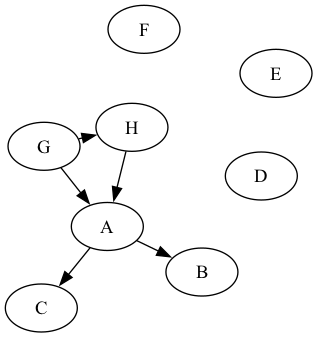

In [60]:
from IPython.display import Image

viz = best_model.to_graphviz()
viz.draw('model_network.png', prog='neato')
Image('model_network.png')

## 3.4. Questions
Based on the previous code provide an answer the following questions:

1. Analyse the results from 3.1 and 3.2
2. Analyse the structure of the obtained network.


### 4. Challenge


1. Consider the file cancer.bif with the cancer disease BN.
2. Load the network and use the method *inference.likelihood_weighted_sample* to sample a minimumm of 5000 examples.
3. Calculate the CPDs and compare with the original ones.
4. Apply diferent strategies (scores and parameters) to determine a BN structure. Compare with the original.






